# Credit Scoring & PD Model

## Library

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

## Datensatz

In [9]:
df_train = pd.read_csv('/Users/adhyutabuananda/Library/Mobile Documents/com~apple~CloudDocs/BUZZMEKK/Productivity/Project/credit-scoring-pd-model/dataset/raw/GiveMeSomeCredit-training.csv')
df_test = pd.read_csv('/Users/adhyutabuananda/Library/Mobile Documents/com~apple~CloudDocs/BUZZMEKK/Productivity/Project/credit-scoring-pd-model/dataset/raw/GiveMeSomeCredit-testing.csv')

In [10]:
df_train.head()

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [12]:
df_test.head()

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,NaN,0.885519,43,0,0.177513,5700.0,4,0,0,0,0.0
1,2,NaN,0.463295,57,0,0.527237,9141.0,15,0,4,0,2.0
2,3,NaN,0.043275,59,0,0.687648,5083.0,12,0,1,0,2.0
3,4,NaN,0.280308,38,1,0.925961,3200.0,7,0,2,0,0.0
4,5,NaN,1.000000,27,0,0.019917,3865.0,4,0,0,0,1.0


### Spaltenumbenennung

In [13]:
df_train.drop('Unnamed: 0', axis=1, inplace=True)
df_test.drop('Unnamed: 0', axis=1, inplace=True)

In [14]:
col_rename = {
    'SeriousDlqin2yrs':                         'default',
    'RevolvingUtilizationOfUnsecuredLines':      'utilization',
    'age':                                       'age',
    'NumberOfTime30-59DaysPastDueNotWorse':      'past_due_30_59',
    'DebtRatio':                                 'debt_ratio',
    'MonthlyIncome':                             'monthly_income',
    'NumberOfOpenCreditLinesAndLoans':           'open_credit_lines',
    'NumberOfTimes90DaysLate':                   'past_due_90',
    'NumberRealEstateLoansOrLines':              'real_estate_loans',
    'NumberOfTime60-89DaysPastDueNotWorse':      'past_due_60_89',
    'NumberOfDependents':                        'num_dependents'
}
df_train.rename(columns=col_rename, inplace=True)
df_test.rename(columns=col_rename, inplace=True)


In [16]:
df_train.head()

,default,utilization,age,past_due_30_59,debt_ratio,monthly_income,open_credit_lines,past_due_90,real_estate_loans,past_due_60_89,num_dependents
0,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [15]:
df_test.head()

,default,utilization,age,past_due_30_59,debt_ratio,monthly_income,open_credit_lines,past_due_90,real_estate_loans,past_due_60_89,num_dependents
0,NaN,0.885519,43,0,0.177513,5700.0,4,0,0,0,0.0
1,NaN,0.463295,57,0,0.527237,9141.0,15,0,4,0,2.0
2,NaN,0.043275,59,0,0.687648,5083.0,12,0,1,0,2.0
3,NaN,0.280308,38,1,0.925961,3200.0,7,0,2,0,0.0
4,NaN,1.000000,27,0,0.019917,3865.0,4,0,0,0,1.0


### Grundstatistiken

In [18]:
print(f"Trainingsdatensatz: {df_train.shape[0]} Zeilen, {df_train.shape[1]} Spalten")
print(f"Testdatensatz: {df_test.shape[0]} Zeilen, {df_test.shape[1]} Spalten")


Trainingsdatensatz: 150000 Zeilen, 11 Spalten
Testdatensatz: 101503 Zeilen, 11 Spalten


In [ ]:
print(df_train.describe())

             default    utilization            age  past_due_30_59  \
count  150000.000000  150000.000000  150000.000000   150000.000000   
mean        0.066840       6.048438      52.295207        0.421033   
std         0.249746     249.755371      14.771866        4.192781   
min         0.000000       0.000000       0.000000        0.000000   
25%         0.000000       0.029867      41.000000        0.000000   
50%         0.000000       0.154181      52.000000        0.000000   
75%         0.000000       0.559046      63.000000        0.000000   
max         1.000000   50708.000000     109.000000       98.000000   

          debt_ratio  monthly_income  open_credit_lines    past_due_90  \
count  150000.000000    1.202690e+05      150000.000000  150000.000000   
mean      353.005076    6.670221e+03           8.452760       0.265973   
std      2037.818523    1.438467e+04           5.145951       4.169304   
min         0.000000    0.000000e+00           0.000000       0.000000   

In [22]:
print(f"Fehlende Werte im Trainingsdatensatz:\n{df_train.isnull().sum()}")

Fehlende Werte im Trainingsdatensatz:
default                  0
utilization              0
age                      0
past_due_30_59           0
debt_ratio               0
monthly_income       29731
open_credit_lines        0
past_due_90              0
real_estate_loans        0
past_due_60_89           0
num_dependents        3924
dtype: int64


In [25]:
print(df_train['default'].value_counts(normalize=True))

default
0    0.93316
1    0.06684
Name: proportion, dtype: float64


### Visualisierung

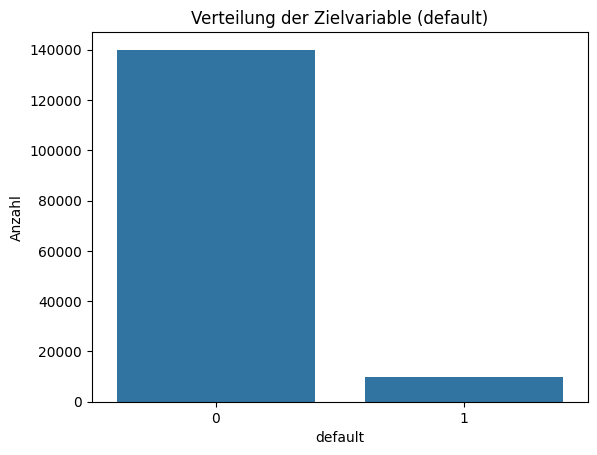

<Figure size 640x480 with 0 Axes>

In [ ]:
sns.countplot(x='default', data=df_train)
plt.title('Verteilung der Zielvariable (default)')
plt.xlabel('default')
plt.ylabel('Anzahl')
plt.show()

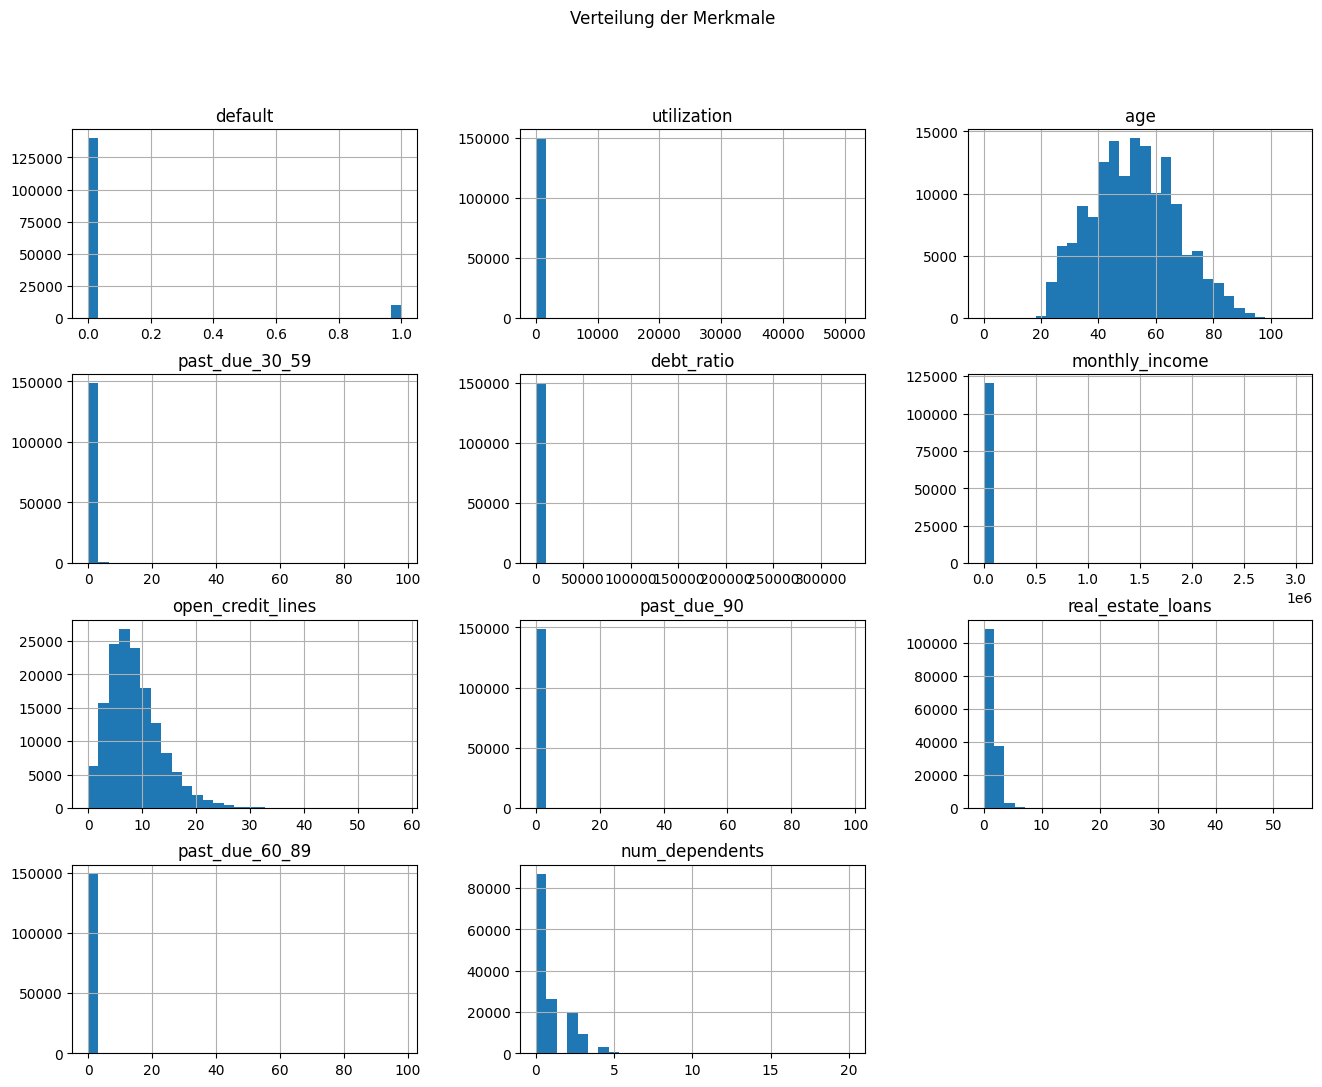

<Figure size 640x480 with 0 Axes>

In [34]:
df_train.hist(figsize=(16, 12),
              bins = 30)
plt.suptitle('Verteilung der Merkmale')
plt.show()
plt.tight_layout()

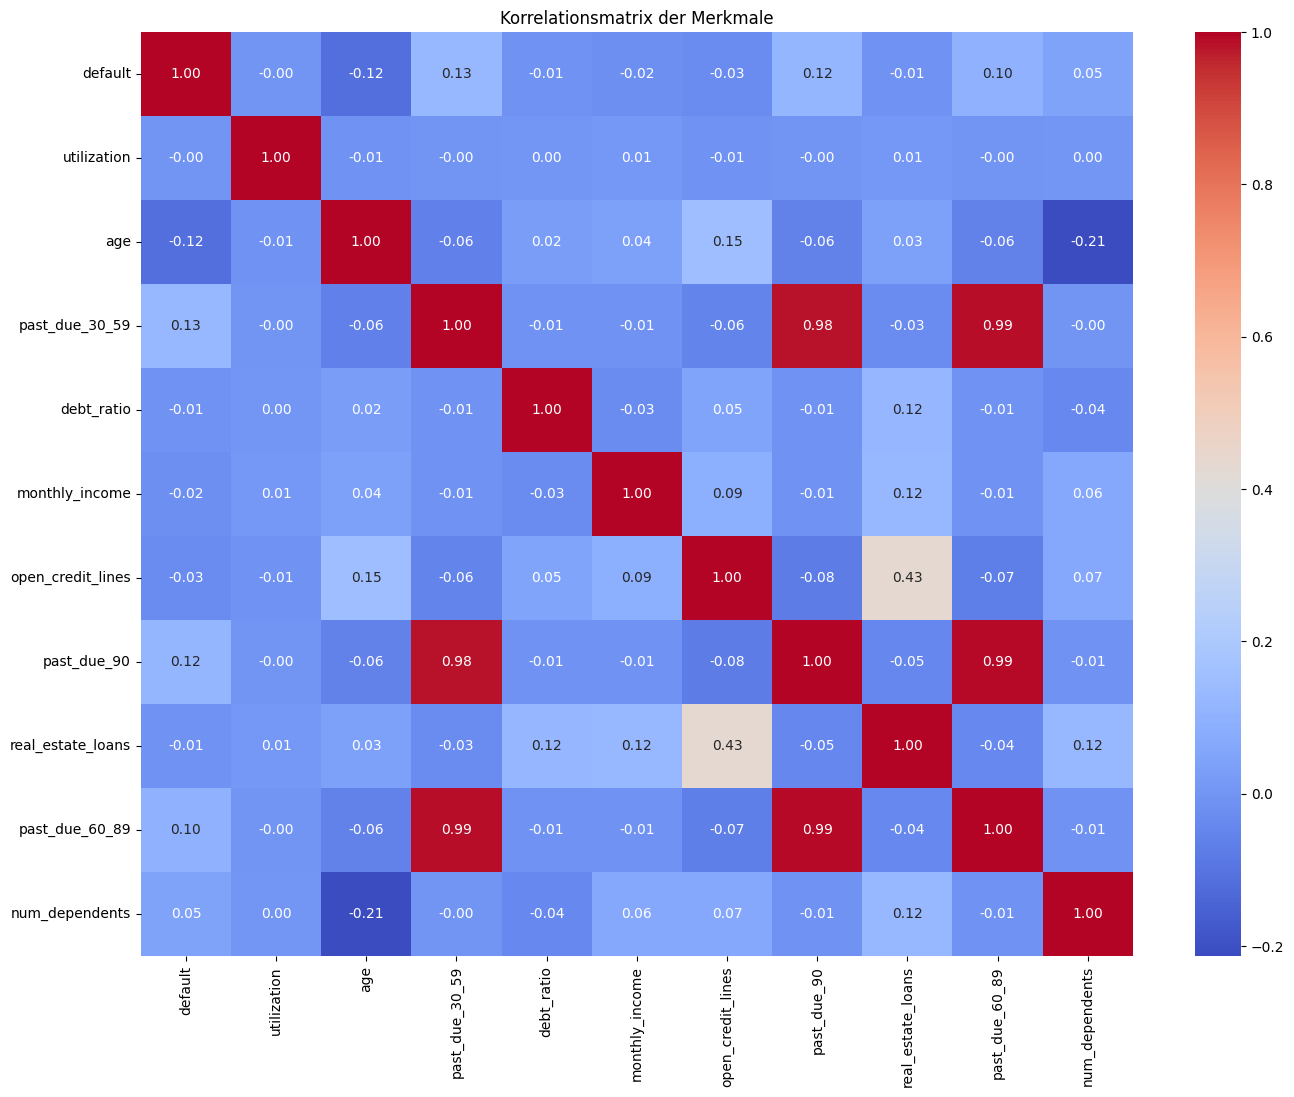

In [35]:
corr = df_train.corr()
plt.figure(figsize=(16, 12))
sns.heatmap(corr,
            annot=True,
            cmap='coolwarm',
            fmt='.2f')
plt.title('Korrelationsmatrix der Merkmale')
plt.show()

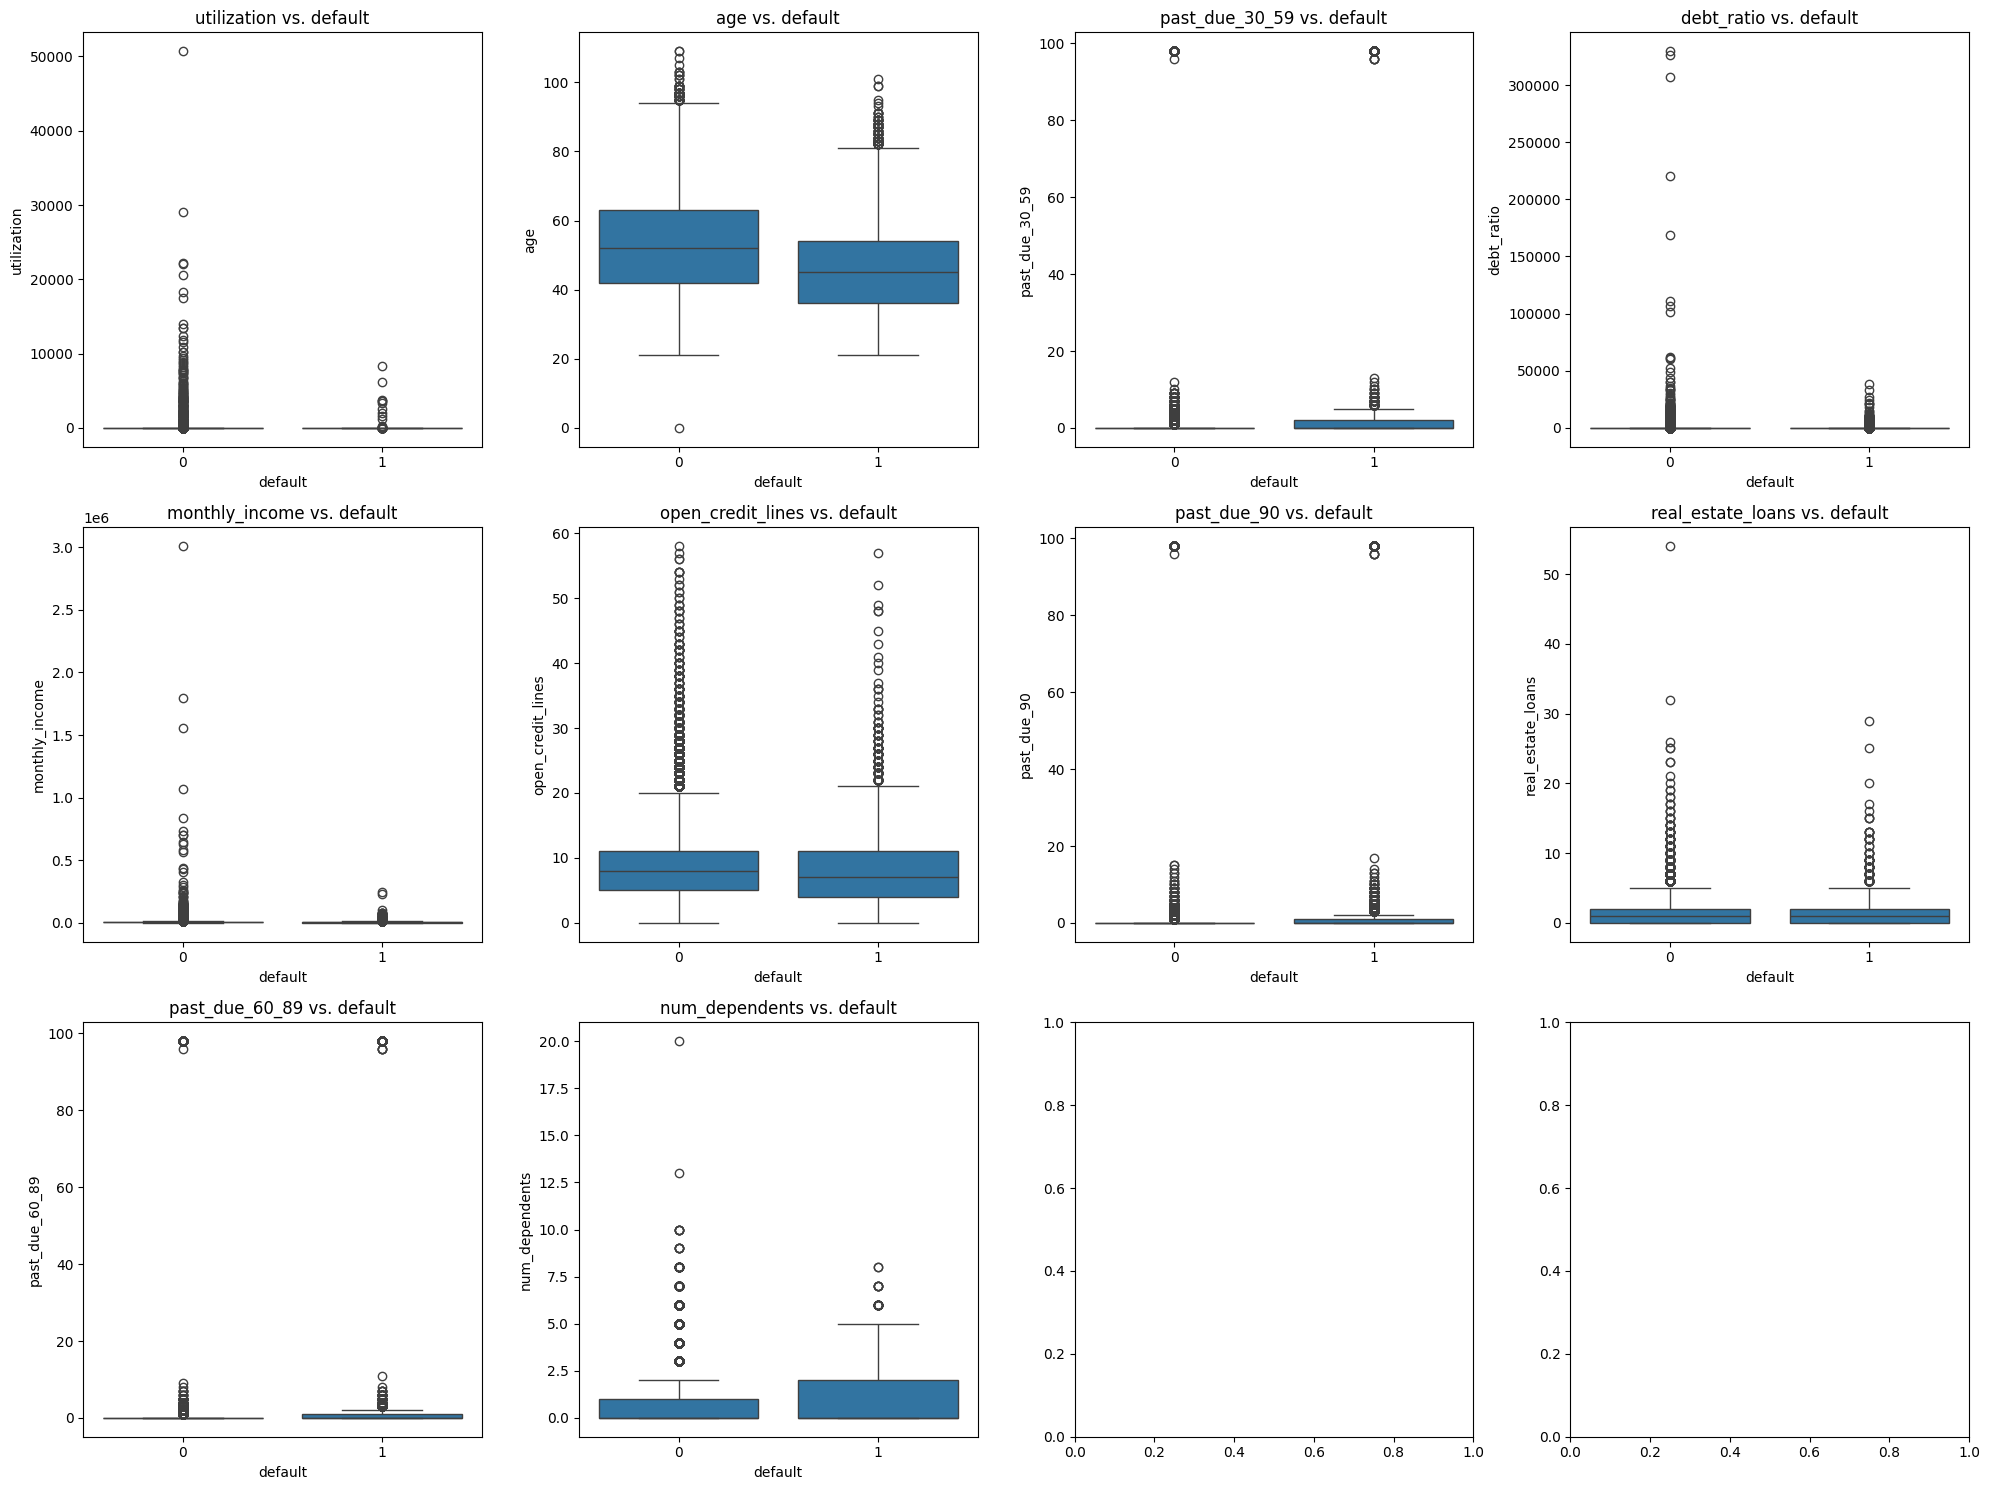

In [36]:
fig, axes = plt.subplots(3, 4,
                         figsize=(20, 15))
features = df_train.columns.drop('default')
for i, feature in enumerate(features):
    row = i // 4
    col = i % 4
    sns.boxplot(x='default',
                y=feature,
                data=df_train,
                ax=axes[row, col])
    axes[row, col].set_title(f'{feature} vs. default')
plt.tight_layout()
plt.show()

# EDA-Erkenntnisse

- `monthly_income` und `num_dependents`haben fehlende Werte
- `utilization` enthält Extremwerte >1 bis zu 50.000+
- `debt_ratio`enthält ebenfalls unrealistiche Ausreißer
- Stärkeste Prädiktoren für `default`: `past_due_90`, `past_due_30_59`